## Validation of PVade against DuraMAT experimental campaign ##

In [1]:
import pandas as pd
import numpy as np
import yaml
import pickle
import importlib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# spectra
from scipy.signal import welch
from numpy import hanning
import math

# from postprocessing_functions import *
# importlib.reload(postprocessing_functions) # to reload functions without restarting the notebook

In [2]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [3]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
# casepath = 'y20m_turbinflow_duramat_validation/'

# casepath = 'halfwing_turbinflow_duramat_validation_40.0deg/'
# exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_neg40deg/'
# exp_data_fn = 'DuraMAT_tiltneg40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_-10.0deg/'
# exp_data_fn = 'DuraMAT_tiltneg10deg_turbulent_inflow_10min_timeseries.csv'

casepath = 'halfwing_turbinflow_duramat_validation_10.0deg/'
exp_data_fn = 'DuraMAT_tilt10deg_turbulent_inflow_10min_timeseries.csv'

tilts = [10.0]
# panel_span = 10.0
# panel_chord = 4.1

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [4]:
# read in lift and drag
output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
loadsdata = tmp

# read in accelerations
tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
#handling runs with updated outputs
if 'deformation' in tmp2.columns[0]:
    loadsdata['accel-x'] = tmp2['x-acceleration'].values
    loadsdata['accel-y'] = tmp2['y-acceleration'].values
    loadsdata['accel-z'] = tmp2['z-acceleration'].values
    loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2
else:
    loadsdata['accel-x'] = tmp2['#x-pos'].values
    loadsdata['accel-y'] = tmp2['y-pos'].values
    loadsdata['accel-z'] = tmp2['z-pos'].values
    loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2

# clean up
del tmp
del tmp2

loadsdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude
Time,,,,,,,,,,
0.006,4549.667610,-84.129083,27497.640580,3.171188,-0.058639,19.166278,0.000000,0.000000,0.000000,0.000000
0.012,1288.144141,-26.526722,2604.534551,0.897856,-0.018490,1.815401,1.227434,0.305385,8.933257,81.402942
0.018,222.852096,-4.943538,-1668.446685,0.155331,-0.003446,-1.162933,7.702952,-3.428664,41.178458,1766.756633
0.024,573.651669,-5.735773,911.010869,0.399844,-0.003998,0.634989,16.030972,5.818465,43.931471,2220.820750
0.030,654.874923,-6.107007,1689.067001,0.456458,-0.004257,1.177306,-12.254664,-3.887133,-32.951563,1251.092112
...,...,...,...,...,...,...,...,...,...,...
29.772,226.967430,1.767097,978.651539,0.158200,0.001232,0.682135,0.272199,-0.009038,1.378933,1.975630
29.778,224.425173,1.708521,965.443698,0.156428,0.001191,0.672929,0.280003,0.012121,1.356413,1.918406
29.784,217.405057,-0.003933,943.008884,0.151535,-0.000003,0.657292,0.245857,0.003414,1.311080,1.779387


### Step 2: Read in post-processed velocity data from PVade sim ###

In [5]:
# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt_sim = params['solver']['dt']
dt_xdmf = params['solver']['save_xdmf_interval']
panel_span = params['pv_array']['panel_span']
panel_chord = params['pv_array']['panel_chord']
panel_height = params['pv_array']['elevation']
tf = params['solver']['t_final']
z_max = params['domain']['z_max']

tracker_angle = 10.0 m/s


In [6]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_10.0.pkl
vel data nt, nx, ny, nz =  (2484, 132, 66, 50)
coord nx, ny, nz =  (132, 66, 50)


In [7]:
xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# sonic location
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]

<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_182732/3555775007.py:52: SyntaxWarning: invalid escape sequence '\p'
  axs.plot(u_fit, z_fit, 'r--', label=f'best fit: u*={u_star:.3f}m/s, \n z0={z0:.3f}m, $\psi$={psi:.2f}')


Estimated u_star (friction velocity): 0.450 m/s
Estimated z0 (roughness length): 0.503047 m
Estimated psi (stability parameter): -5.09 m
u_mean at h_panel: 7.151 m/s
perc error of u_mean at h_panel: 0.75 %


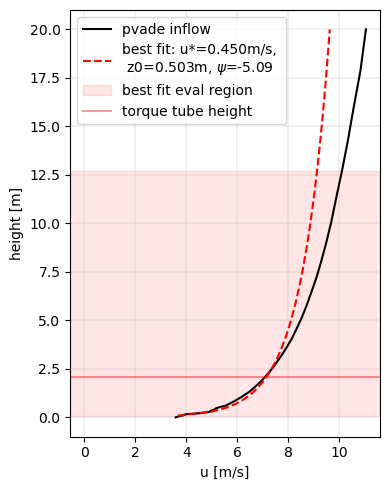

In [9]:
# plot inflow profile and derive best-fit parameters
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

u_profile = np.nanmean(np.nanmean(readdata[tilt]['u'][:,0,:,:], axis=0), axis=0)
interp_func = interp1d(zi, u_profile, kind='linear', fill_value='extrapolate')

z_fit_max_idx = 45

# Define the log law function (neutral stability assumption for simplicity, ψ(z/L) = 0)
def log_law(z, u_star, z0, psi):
    d0 = 0.0
    kappa = 0.41
    u_star = 0.45
    # Guard against invalid log inputs
    valid = np.maximum((z - d0) / z0, 1e-9)
    return (u_star / kappa) * (np.log(valid) - psi)
    # return (u_star / kappa) * (np.log((z - d0) / z0) - psi)

# Assign weights: Emphasize z = panel_height
weights = np.ones_like(zi[1:z_fit_max_idx])
weights[np.argmin(np.abs(zi - panel_height))] += 10  # Increase weight at z = 2.1

# bounds=([u_star min, z0 min, psi min], [u_star max, z0 max, psi max])
bounds=([0.3, 1e-5, -10],[0.7, 1, 1])

# Initial guess (optional)
p0 = [0.45, 1e-2, -3]

# Fit the log law equation to the data
popt, pcov = curve_fit(log_law, zi[1:z_fit_max_idx], u_profile[1:z_fit_max_idx], sigma=1/weights, bounds=bounds, p0=p0)
u_star, z0, psi = popt

# Print results
print(f"Estimated u_star (friction velocity): {u_star:.3f} m/s")
print(f"Estimated z0 (roughness length): {z0:.6f} m")
print(f"Estimated psi (stability parameter): {psi:.2f} m")

# for pvade inflow
u_fit_h_panel = log_law(panel_height, u_star, z0, psi)
u_pvade_h_panel = interp_func(panel_height)
error_h_panel = (u_fit_h_panel - u_pvade_h_panel)/u_pvade_h_panel * 100
print(f"u_mean at h_panel: {u_fit_h_panel:.3f} m/s")
print(f"perc error of u_mean at h_panel: {error_h_panel:.2f} %")

# Plot the results
z_fit = np.linspace(min(zi[1:]), max(zi[1:]), 100)
u_fit = log_law(z_fit, u_star, z0, psi)

fig, axs = plt.subplots(figsize=[4,5])
axs.plot(u_profile, zi, 'k', label='pvade inflow')
axs.plot(u_fit, z_fit, 'r--', label=f'best fit: u*={u_star:.3f}m/s, \n z0={z0:.3f}m, $\psi$={psi:.2f}')
axs.axhspan(zi[1],zi[z_fit_max_idx], color='r', alpha=0.1, label='best fit eval region')
axs.axhline(panel_height, color='r', alpha=0.4, label='torque tube height')
axs.set_xlabel('u [m/s]')
axs.set_ylabel('height [m]')
axs.grid(lw=0.25)
axs.legend()

plt.tight_layout()

In [10]:
# create dataframe from velocity data
nt = np.shape(readdata[tilt]['u'])[0]
time_xdmf = np.arange(dt_xdmf, tf+dt_xdmf, dt_xdmf)[0:nt] #np.linspace(dt_xdmf, tf, nt)

# velocity signal at sonic location
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = pd.DataFrame(index=time_xdmf)
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s)'] = readdata[tilt][comp][:,0,j,k]


In [11]:
# merge sim data
sim_data = pd.merge(loadsdata, vel_data, left_index=True, right_index=True, how='inner')
sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s)
0.012,1288.144141,-26.526722,2604.534551,0.897856,-0.018490,1.815401,1.227434,0.305385,8.933257,81.402942,NaN,NaN,NaN
0.024,573.651669,-5.735773,911.010869,0.399844,-0.003998,0.634989,16.030972,5.818465,43.931471,2220.820750,NaN,NaN,NaN
0.048,806.923973,-6.578518,2936.831918,0.562438,-0.004585,2.047017,14.651916,-0.852860,42.820499,2049.001176,NaN,NaN,NaN
0.060,335.868680,-5.855897,422.126265,0.234106,-0.004082,0.294228,-18.000609,0.381820,-59.236368,3833.114941,NaN,NaN,NaN
0.072,406.269738,-4.690095,1000.976463,0.283176,-0.003269,0.697696,8.199410,1.224684,36.152632,1375.743006,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,248.444537,2.877947,1059.879377,0.173170,0.002006,0.738752,0.246020,-0.002860,1.332169,1.835207,4.552465,1.656715,0.137988
29.736,250.981381,2.813360,1065.366344,0.174938,0.001961,0.742577,0.317017,0.000477,1.499986,2.350458,4.500615,1.676594,-0.457198
29.748,229.177593,2.580162,990.362820,0.159740,0.001798,0.690298,0.213293,0.001959,1.131546,1.325894,4.682059,1.734882,-0.299325
29.760,225.031181,2.499983,974.987322,0.156850,0.001743,0.679581,0.252250,-0.021656,1.227771,1.571521,5.183364,1.795706,-0.487819


In [12]:
# calculate lift and drag coeff
sfc_area = panel_span * panel_chord
sim_data['vel_mag (m/s)'] = (sim_data['u (m/s)']**2 + sim_data['v (m/s)']**2 + sim_data['w (m/s)']**2)**0.5
sim_data['fx_nd_calc'] = (sim_data['fx_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)
sim_data['fz_nd_calc'] = (sim_data['fz_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)

### Step 3: read in measurement data from DuraMAT ###

In [13]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data
    
raw_exp_data = pd.read_csv(exp_data_fn, index_col='Time')
raw_exp_data.index = pd.to_datetime(raw_exp_data.index)

tf_sonic1, exp_data = read_csv_data(raw_exp_data)
dt_exp = exp_data.index[1]-exp_data.index[0]

# cut sonic data to time period simulated
if tilt == -40.0:
    tstart = 250.0
elif tilt == 40.0:
    tstart = 0.0
elif tilt == -10.0:
    tstart = 280.0
elif tilt == 10.0:
    tstart = 100.0

exp_data = exp_data[exp_data.index >= tstart]
exp_data = exp_data[exp_data.index <= sim_data.index[-1]+tstart]
exp_data.index = exp_data.index - tstart
exp_data = exp_data[exp_data.index > 0.0]

exp_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN),AccNW X (g),AccNW Y (g),AccNE X (g),AccNE Y (g)
Time,,,,,,,,,,,,,,,,,
0.02,7.907073,274.32540,7.703037,0.582628,-1.686880,13.889259,10.387813,-1.089934,0.174328,0.229691,1.302640,0.238502,1.301056,-0.070406,0.006998,-0.948307,0.196429
0.04,7.906747,274.32462,7.702670,0.582493,-1.687079,13.890363,10.386157,-1.077392,0.232079,0.227048,1.287651,0.235721,1.286092,-0.049261,0.000326,-0.976638,0.199251
0.06,7.907787,274.32285,7.703716,0.582336,-1.687231,13.890512,10.384612,-1.070176,0.170254,0.225527,1.279026,0.234107,1.277483,-0.025979,0.002482,-0.902561,0.197470
0.08,7.907148,274.31690,7.703201,0.581492,-1.686878,13.890061,10.383618,-1.101164,0.170215,0.232057,1.316062,0.240863,1.314478,-0.053856,0.004755,-0.907476,0.187758
0.10,7.907863,274.33054,7.703764,0.583378,-1.687004,13.891516,10.386046,-1.135239,0.246817,0.239238,1.356787,0.248374,1.355144,-0.005273,0.006186,-0.936860,0.191959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,5.904249,274.06480,5.879564,0.417820,0.341036,14.182050,10.388916,-0.981149,0.356897,0.206765,1.172625,0.214720,1.171194,0.012802,-0.002189,-1.001268,0.200591
29.72,5.903860,274.06128,5.879199,0.417433,0.341084,14.182175,10.386323,-0.987555,0.358245,0.208115,1.180281,0.216069,1.178851,0.025023,0.001610,-0.986432,0.200415
29.74,5.903860,274.06805,5.879155,0.418129,0.340985,14.182801,10.386378,-0.999402,0.394356,0.210612,1.194440,0.218662,1.192993,0.008004,0.002333,-0.966012,0.197182


In [14]:
# calculate lift and drag force coefficients
exp_data['Drag Coefficient'] = (exp_data['Drag force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)
exp_data['Lift Coefficient'] = (exp_data['Lift force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)

In [22]:
sim_data.index

Index([ 0.012,  0.024,  0.048,   0.06,  0.072,  0.084,  0.096,  0.108,   0.12,
        0.132,
       ...
       29.628,  29.64, 29.652, 29.664, 29.712, 29.724, 29.736, 29.748,  29.76,
       29.796],
      dtype='float64', length=1732)

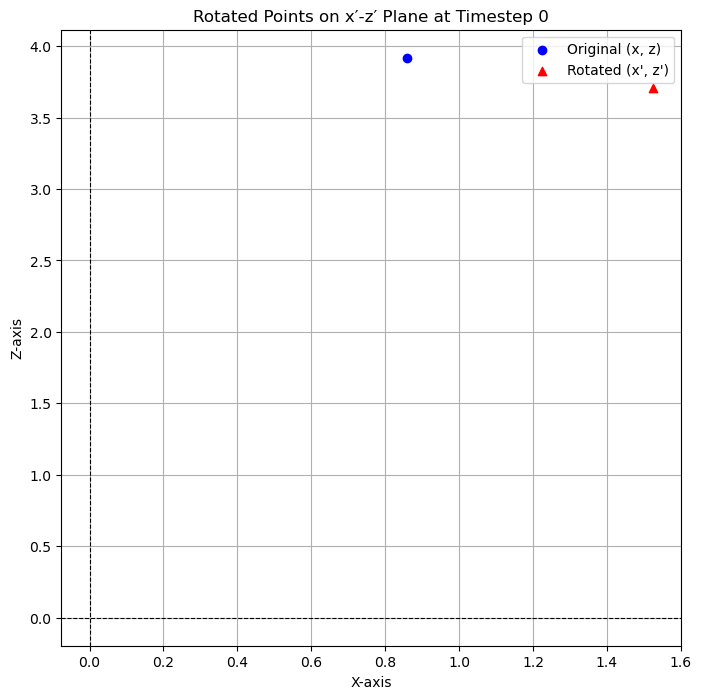

In [29]:
# convert accelerations from pvade coordinate system to that of experimental data
from scipy.spatial.transform import Rotation as R

testdata = sim_data.copy()
testdata = testdata[testdata.index > 2.0]

tracker_angle = tilt

# Make acceleration table shape=(num_steps, 3)
pvade_accel = np.full((np.shape(testdata)[0], 3), np.nan)
pvade_accel[:, 0] = testdata['accel-x']
pvade_accel[:, 1] = testdata['accel-y']
pvade_accel[:, 2] = testdata['accel-z']

# Make a rotation matrix about the y-axis
Ry = R.from_euler("y", tracker_angle, degrees=True).as_matrix()

# Apply the rotation matrix to our simulation data
# Now it should match the experimental setup with the mapping:
# our x = their y
# our y = their z
# our z = their x
experimental_accel = np.dot(pvade_accel, Ry.T)

# Names for axes
original_axes = ["x", "y", "z"]
rotated_axes = ["x'", "y'", "z'"]

# Choose a timestep to visualize (e.g., the first one):
timestep = 0  # Change this index to visualize other timesteps

# Extract rotated x' and z' at the chosen timestep
x_prime = experimental_accel[timestep, 0]  # x' corresponds to column 0
z_prime = experimental_accel[timestep, 2]  # z' corresponds to column 2

# Extract original x and z for comparison (optional)
x_original = pvade_accel[timestep, 0]
z_original = pvade_accel[timestep, 2]

# Scatter all points at the given timestep
plt.figure(figsize=(8, 8))
plt.scatter(pvade_accel[timestep, 0], pvade_accel[timestep, 2], color="blue", label="Original (x, z)", marker="o")
plt.scatter(experimental_accel[timestep, 0], experimental_accel[timestep, 2], color="red", label="Rotated (x', z')", marker="^")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("X-axis")
plt.ylabel("Z-axis")
plt.title(f"Rotated Points on x′-z′ Plane at Timestep {timestep}")
plt.legend()
plt.grid()
plt.show()

# Plot because it needs som pizazz, also, checking
# fig, ax = plt.subplots(3, 1, figsize=(4, 10))
# for idx in range(3):
#     ax[idx].plot(testdata.index, pvade_accel[:, idx], "-", color=f"C{idx}", label="PVade")
#     ax[idx].plot(testdata.index, experimental_accel[:, idx], ".", color=f"C{idx}", label="Experimental")
#     ax[idx].set_ylabel(f"{['x', 'y', 'z'][idx]}-Acceleration")
#     ax[idx].set_xlim([5, 10])

# plt.legend()
# plt.show()

In [15]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = exp_data.index #exp_data[exp_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in sim_data.columns:
    interpolator = interp1d(sim_data.index, sim_data[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc
Time,,,,,,,,,,,,,,,,
0.02,811.815827,-12.666089,1475.518763,0.565848,-0.008828,1.028459,11.096459,3.980772,32.265400,1507.681481,NaN,NaN,NaN,NaN,NaN,NaN
0.04,729.166539,-6.297603,2261.558235,0.508240,-0.004390,1.576341,15.111602,1.370915,43.190823,2106.274368,NaN,NaN,NaN,NaN,NaN,NaN
0.06,335.868680,-5.855897,422.126265,0.234106,-0.004082,0.294228,-18.000609,0.381820,-59.236368,3833.114941,NaN,NaN,NaN,NaN,NaN,NaN
0.08,433.091640,-4.265264,1222.946913,0.301872,-0.002973,0.852413,-3.688744,-0.483868,-11.773154,1373.012317,NaN,NaN,NaN,NaN,NaN,NaN
0.10,196.047642,-2.533069,61.329004,0.136648,-0.001766,0.042747,5.133120,0.320480,14.560401,281.724932,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,245.626847,3.273309,1054.312597,0.171206,0.002282,0.734872,0.368535,0.001422,1.729613,3.340468,4.786097,1.549652,1.061516,5.145891,0.346733,1.488295
29.72,247.075416,2.897654,1056.179228,0.172215,0.002020,0.736173,0.310420,0.004130,1.550125,2.602669,4.592596,1.651237,0.450164,4.920213,0.381546,1.630808
29.74,243.713452,2.735627,1040.365169,0.169872,0.001907,0.725151,0.282443,0.000971,1.377172,2.008936,4.561096,1.696023,-0.404574,4.883684,0.382251,1.631304


In [ ]:
# merge dataframes
alldata = {}

alldata['exp'] = exp_data.copy()
alldata['sim'] = sim_data.copy()
alldata['sim_interp'] = interp_sim_data.copy()

# adjustments
alldata['exp'] = alldata['exp'].rename(columns={'3D wind speed (m/s)':'vel_mag (m/s)'})

for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    alldata['sim_interp'][comp+'_0'] = alldata['sim_interp'][comp+'_0']/1000

for key in ['sim','sim_interp']:
    alldata[key] = alldata[key].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)',
                                               'fx_nd_calc':'Drag Coefficient','fz_nd_calc':'Lift Coefficient', 
                                                'accel-x':'AccNE X (g)', 'accel-z':'AccNE Y (g)'})
    # alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})
    # alldata['sim_interp'] = alldata['sim_interp'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

In [ ]:
# plot velocity signals and drag and lift force
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [ ]:
# plot velocity signals and accelerations
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','AccNE X (g)','AccNE Y (g)']
# vars = ['exp']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [ ]:
# compute errors
keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
baseline = 'exp'

error_list = []
error_df = {}

mean_abs_err = {}
mean_perc_err = {}
for key in keys:
    mean_abs_err[key] = {}
    mean_perc_err[key] = {}
    for comp in comps:
        mean_abs_err[key][comp] = round(float(np.nanmean(alldata[key][comp].values - alldata[baseline][comp].values)),4)
        mean_perc_err[key][comp] = 100*round(float(np.nanmean((alldata[key][comp].values - alldata[baseline][comp].values)/alldata[baseline][comp].values)),3)

        # Append results as a dictionary to the error list
        error_list.append({
            'Variable': comp,
            'Mean_Absolute_Error': mean_abs_err[key][comp],
            'Mean_Percent_Error [%]': mean_perc_err[key][comp]
        })

    error_df[key] = pd.DataFrame(error_list).set_index('Variable')
error_df[key]

In [ ]:
# compute stats
# histograms
time_threshold = 2.0

vars_for_stats = ['u (m/s)', 'v (m/s)', 'w (m/s)', 
        'Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

statistics_list = []

for var in vars_for_stats:
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        
        stats = {
            'Key': f"{key}",
            'Var': f"{var}",
            'Mean': np.nanmean(pltdata.values),
            'Median': np.nanmedian(pltdata.values),
            'Max': np.max(pltdata.values),
            'Min': np.min(pltdata.values),
            'Std Dev': np.std(pltdata.values)
        }
        statistics_list.append(stats)

statistics_df = pd.DataFrame(statistics_list).set_index('Key')
statistics_df.round(3)

In [ ]:
# histograms
time_threshold = 2.0

vars = ['Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,2,figsize=[10,5]) #, dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

statistics_list = []

for var,ax in zip(vars, axs.ravel()):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        
        ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
        ax.axvline(np.mean(pltdata.values), color=colors[key], label='')
        ax.set_xlabel(var)
        ax.legend()

for ax in axs.ravel():
    ax.grid(lw=0.25)
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()

In [ ]:
# compute flow metrics
def compute_TI(u,v,w):
    umag = (u**2 + v**2 + w**2)**0.5
    
    Iu = np.std(u, axis=0) / np.mean(umag, axis=0)
    Iv = np.std(v, axis=0) / np.mean(umag, axis=0)
    Iw = np.std(w, axis=0) / np.mean(umag, axis=0)

    return Iu, Iv, Iw

# Collect TI data for each dataset
TI_list = []  # Empty list to hold the results for the DataFrame

for key in alldata.keys():
    Iu, Iv, Iw = compute_TI(alldata[key]['u (m/s)'], alldata[key]['v (m/s)'], alldata[key]['w (m/s)'])
    
    # Append the results as a dictionary to the list
    TI_list.append({
        'Key': key,  # Use `key` to identify the dataset
        'Iu': round(Iu, 3),
        'Iv': round(Iv, 3),
        'Iw': round(Iw, 3)
    })

# Convert the list of dictionaries to a DataFrame
TI_df = pd.DataFrame(TI_list).set_index('Key')

# Print the resulting DataFrame
TI_df

In [ ]:
# Smooth high frequency region
def runningMeanFast(x, N):
    """
    Calculates the running mean of an array x over a window size N.

    Returns:
        np.ndarray: Smoothed signal
    """
    return np.convolve(x, np.ones(N)/N, mode='same') 

def compute_spectra(u, U_mean, height, fs, overlap):
    """
    Computes the normalized energy spectrum of a velocity time series `u`,
    smooths the high-frequency tail, and returns the normalized frequency
    and smoothed normalized power spectral density.

    Parameters:
        u (array-like): Time series of velocity fluctuations (1D)
        U_mean (float): Mean flow velocity (for normalization)
        height (float): Reference height (for normalization)
        fs (float): Sampling frequency [Hz]
        overlap (int): Number of samples to overlap in Welch’s method

    Returns:
        nf_U_corr (np.ndarray): Normalized frequency array
        nPxxf_mod_U_corr (list of np.ndarray): Concatenated original and smoothed
            normalized power spectral density
    """

    # Length of the input time series (used for FFT size and window)
    nblock = len(u)

    # Use a Hamming window for spectral estimation
    win = np.hamming(math.floor(nblock/10))

    # Convert u to a pandas Series for easier handling (e.g., dropna, stats)
    U_corr = pd.Series(u)
    # do I need to detrend this? - probably not bc of "detrend = constant" in welch function call

    # Standard deviation of the fluctuations (used to normalize PSD)
    u_std = U_corr.std()

    # Compute power spectral density using Welch's method
    f_U_corr, Pxxf_U_corr = welch(U_corr.dropna(), fs, window=win, noverlap=overlap, nfft=nblock, detrend='constant', return_onesided=True) # detrend constant removes mean (zero-mean segments)
    
    # Normalize frequency: non-dimensional frequency = f * z / U_mean
    nf_U_corr = f_U_corr*height/abs(U_mean)

    # Normalize power: dimensionless spectral density
    nPxxf_U_corr = (f_U_corr*Pxxf_U_corr)/u_std**2

    # Identify index where normalized frequency > 0.3 (start smoothing here)
    index_highfreq_U_corr = list(np.where([abs(nf_U_corr)>0.3]))

    # Extract the high-frequency tail to smooth
    nPxxf_smooth_U_corr = nPxxf_U_corr[index_highfreq_U_corr[0][0]:len(nPxxf_U_corr)]

    # Apply running mean to smooth the high-frequency region
    avg_window_size = int(nblock/6)
    nPxxf_smooth_U_corr = runningMeanFast(nPxxf_smooth_U_corr,avg_window_size) # 200)

    # Concatenate the low-frequency part (unsmoothed) with the smoothed tail
    # nPxxf_mod_U_corr = [nPxxf_U_corr[0:index_highfreq_U_corr[0][0]-1],nPxxf_smooth_U_corr]
    nPxxf_mod_U_corr = nPxxf_U_corr # without smoothing

    # return nf_U_corr, nPxxf_mod_U_corr
    return nf_U_corr, nPxxf_mod_U_corr

In [ ]:
# spectra of flow
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['u','v','w','vel_mag']

nf_corr = {}; nPxxf_mod_corr = {}
U_mean = {}

for var in vars:
    U_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        U_mean[var][comp] = float(np.nanmean(alldata[var][comp+' (m/s)'].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp+' (m/s)'].values.squeeze(), U_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,4, figsize=[12,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

In [ ]:
# spectra of loads
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['Drag force (kN)', 'Lift force (kN)']

nf_corr = {}; nPxxf_mod_corr = {}
comp_mean = {}

for var in vars:
    comp_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        comp_mean[var][comp] = float(np.nanmean(alldata[var][comp].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp].values.squeeze(), comp_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,2, figsize=[7,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

In [ ]:
# # first glance at drag and lift forces
# plt.style.use('default')
# time_threshold = 2.0 #12.0 # s

# vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
# colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}
# keys = ['sim','sim_interp','exp']

# fig, axs = plt.subplots(2,2,figsize=[10,5],sharex=True) #, dpi=300) #, sharey=True)
# # plt.suptitle('u='+u+' m/s')
# # for n,var in enumerate(vars):
# for var,ax in zip(vars, axs.ravel()):
#     for key in keys:
#         pltdata = alldata[key][var][alldata[key][var].index > 2.0]
#         ax.plot(pltdata, label=key, color=colors[key])
#         ax.axvline(time_threshold, linestyle=':', color='k')
#         ax.set_ylabel(var)
#         # ax.legend()
#         # axs[0].set_xlim([15, 20])
#         # axs[0].set_ylim([0.0, 4.0])

# for ax in axs.ravel():
#     ax.grid(lw=0.25)
#     # ax.legend()

# for ax in axs[-1,:]:
#     ax.set_xlabel('time [s]')

# axs[-1,-1].legend()

# plt.tight_layout()

In [ ]:
# # plot velocity signals
# fig, axs = plt.subplots(4,1, figsize=[8,6], sharex=True)

# comps = ['u','v','w','vel_mag']
# vars = ['sim','sim_interp','exp']
# # vars = ['exp']

# for comp,ax in zip(comps, axs.ravel()):
#     for var in vars:
#         ax.plot(alldata[var][comp+' (m/s)'], label=var, alpha=0.8, color=colors[var])
#         ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()

In [ ]:
# # if needed for debugging: plot signal from h5 file and sonic
# import h5py

# turb_h5_fname = '/projects/pvopt/aps_dfd_2024/PVade/input/pct_constrained_turb_ny154_nz38_sonic1_30s_u9.0_50Hz.h5'
# sim_turb_data = {}

# with h5py.File(turb_h5_fname, "r") as fp:
#     for key, val in fp.items():
#         print(key, val.shape, val.dtype)

#     t_fp = fp["time_index"][:]
#     y_fp = fp["y_coordinates"][:]
#     z_fp = fp["z_coordinates"][:]

#     # comp="u"
#     # fig, ax = plt.subplots()
#     # plt.suptitle('pyconturb flowfield')
#     # plt.imshow(fp[comp][0, :, :],  # imshow requires nz-ny slice
#     #             origin='lower',  # smallest y-z in lower left, not upper left
#     #             extent=[y_fp[0], y_fp[-1], z_fp[0], z_fp[-1]],  # lateral and vertical limits
#     #             interpolation='bilinear',
#     #             cmap='coolwarm')  # image smoothing
#     # plt.colorbar(label=comp)

#     sim_turb_data["u"] = fp["u"][:, :, :]
#     sim_turb_data["v"] = fp["v"][:, :, :]
#     sim_turb_data["w"] = fp["w"][:, :, :]

# jp = int(np.argmin(np.abs(y_fp - yloc)))
# kp = int(np.argmin(np.abs(z_fp - zloc)))
# # print(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')

# fig, axs = plt.subplots(3,1, figsize=[8,6], sharex=True)
# plt.suptitle(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')
# for comp,ax in zip(['u','v','w'], axs.ravel()):
#     ax.plot(t_fp,sim_turb_data[comp][:,kp,jp], label='pyconturb')
#     ax.plot(alldata['sim'][comp+' (m/s)'], label='pvade at inlet')
#     ax.plot(alldata['exp'][comp+' (m/s)'], 'k', label='experimental')
#     ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()